In [1]:
!pip install optuna sentence-transformers scikit-learn pandas numpy matplotlib pyyaml --quiet

In [2]:
import os
import math
import time
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import optuna
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All imports OK ✅")

All imports OK ✅


In [3]:
chunks_df = pd.read_csv('chunks_final.csv')
chunks_df = chunks_df.dropna(subset=['chunk_text']).reset_index(drop=True)
texts = chunks_df['chunk_text'].astype(str).tolist()

print(f"Total chunks   : {len(chunks_df)}")
print(f"Unique papers  : {chunks_df['paper_id'].nunique()}")
print(f"Columns        : {chunks_df.columns.tolist()}")
chunks_df.head(3)

Total chunks   : 1958
Unique papers  : 99
Columns        : ['chunk_id', 'paper_id', 'title', 'pdf_file', 'page', 'chunk_number', 'chunk_text']


,chunk_id,paper_id,title,pdf_file,page,chunk_number,chunk_text
0,1,paper_001,retrieval augmented generation for knowledge i...,retrieval_augmented_generation_for_knowledge_i...,1,1,Retrieval-Augmented Generation for Knowledge-I...
1,2,paper_001,retrieval augmented generation for knowledge i...,retrieval_augmented_generation_for_knowledge_i...,2,1,The Divine Comedy (x) q Query Encoder q(x) MIP...
2,3,paper_001,retrieval augmented generation for knowledge i...,retrieval_augmented_generation_for_knowledge_i...,3,1,by θ that generates a current token based on a...


In [4]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf = vectorizer.fit_transform(texts)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (1958, 10000)


In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
)

np.save('embeddings.npy', embeddings)

print(f"Embeddings shape: {embeddings.shape}")
print("Saved to embeddings.npy ✅")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Embeddings shape: (1958, 384)
Saved to embeddings.npy ✅


In [6]:
mask = (
    ~chunks_df['chunk_text'].str.contains(r'\[\d+\]', regex=True) &
    ~chunks_df['chunk_text'].str.contains(r'arXiv', case=False) &
    (chunks_df['chunk_text'].str.len() > 300)
)

clean = chunks_df[mask].reset_index(drop=True)
sample = clean.sample(30, random_state=SEED).reset_index(drop=True)

queries_df = pd.DataFrame({
    'query': sample['chunk_text'].str.slice(0, 120),
    'relevant_chunk_id': sample['chunk_id'].astype(str)
})

queries_df.to_csv('gold_queries.csv', index=False)
print(f"Gold queries created: {len(queries_df)}")
queries_df.head(5)

Gold queries created: 30


,query,relevant_chunk_id
0,Technical Report Table 8: Statistical informat...,355
1,Published as a conference paper at ICLR 2026 F...,1124
2,"and metadata- based approaches, which can be d...",309
3,"Sewon Min, Mike Lewis, Luke Zettlemoyer, and H...",930
4,Improving language models by retrieving from t...,144


In [7]:
def recall_at_k(retrieved_ids, relevant_id, k=5):
    """Did the correct chunk appear in the top-k results? 1=yes, 0=no"""
    return int(relevant_id in retrieved_ids[:k])


def ndcg_at_k(retrieved_ids, relevant_id, k=5):
    """How highly ranked was the correct chunk? Higher rank = higher score"""
    for i, doc_id in enumerate(retrieved_ids[:k]):
        if doc_id == relevant_id:
            return 1.0 / math.log2(i + 2)
    return 0.0


print("Metric functions ready ✅")

Metric functions ready ✅


In [8]:
def minmax_norm(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)


def hybrid_search_baseline(query, top_k=5, alpha=0.7):
    # TF-IDF scores
    q_vec = vectorizer.transform([query])
    tfidf_scores = cosine_similarity(q_vec, X_tfidf).flatten()

    # Dense scores
    q_emb = model.encode(query, convert_to_numpy=True, normalize_embeddings=True)
    dense_scores = np.dot(embeddings, q_emb)

    # Combine
    final = alpha * minmax_norm(dense_scores) + (1 - alpha) * minmax_norm(tfidf_scores)
    top_idx = final.argsort()[::-1][:top_k]
    return chunks_df.iloc[top_idx]['chunk_id'].astype(str).tolist()


# Run baseline on all 30 gold queries
recalls, ndcgs, latencies = [], [], []

for _, row in queries_df.iterrows():
    q   = row['query']
    rel = str(row['relevant_chunk_id'])

    t0 = time.time()
    ids = hybrid_search_baseline(q, top_k=5, alpha=0.7)
    latencies.append(time.time() - t0)

    recalls.append(recall_at_k(ids, rel, k=5))
    ndcgs.append(ndcg_at_k(ids, rel, k=5))

baseline_recall  = round(np.mean(recalls), 4)
baseline_ndcg    = round(np.mean(ndcgs), 4)
baseline_latency = round(np.percentile(latencies, 95), 4)

print("=== BASELINE METRICS ===")
print(f"  Recall@5      : {baseline_recall}")
print(f"  NDCG@5        : {baseline_ndcg}")
print(f"  P95 Latency   : {baseline_latency}s")

=== BASELINE METRICS ===
  Recall@5      : 0.9
  NDCG@5        : 0.8274
  P95 Latency   : 0.0852s


In [9]:
_svd_cache = {}

def get_svd_matrix(svd_dim, normalize_vecs):
    """Build and cache SVD-compressed TF-IDF matrix."""
    key = (svd_dim, normalize_vecs)
    if key not in _svd_cache:
        svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
        mat = svd.fit_transform(X_tfidf)
        if normalize_vecs:
            mat = normalize(mat, norm='l2')
        _svd_cache[key] = (svd, mat)
    return _svd_cache[key]


def objective(trial):
    # Optuna picks these values automatically each trial
    k           = trial.suggest_int('k', 3, 15)
    alpha       = trial.suggest_float('alpha', 0.0, 1.0)
    svd_dim     = trial.suggest_int('svd_dim', 50, 500, step=50)
    norm_vecs   = trial.suggest_categorical('normalization', [True, False])
    metric      = trial.suggest_categorical('metric', ['cosine', 'euclidean'])

    svd_model, svd_mat = get_svd_matrix(svd_dim, norm_vecs)

    ndcgs, recalls, lats = [], [], []

    for _, row in queries_df.iterrows():
        q   = row['query']
        rel = str(row['relevant_chunk_id'])

        t0 = time.time()

        # Dense scores
        q_emb = model.encode(q, convert_to_numpy=True, normalize_embeddings=True)
        dense_scores = np.dot(embeddings, q_emb)

        # SVD-compressed TF-IDF scores
        q_tfidf = vectorizer.transform([q])
        q_svd   = svd_model.transform(q_tfidf)
        if norm_vecs:
            q_svd = normalize(q_svd, norm='l2')

        if metric == 'cosine':
            tfidf_scores = cosine_similarity(q_svd, svd_mat).flatten()
        else:
            dists = euclidean_distances(q_svd, svd_mat).flatten()
            tfidf_scores = 1.0 / (1.0 + dists)

        # Combine
        final = alpha * minmax_norm(dense_scores) + (1 - alpha) * minmax_norm(tfidf_scores)
        top_idx = final.argsort()[::-1][:k]
        ids = chunks_df.iloc[top_idx]['chunk_id'].astype(str).tolist()

        lats.append(time.time() - t0)
        recalls.append(recall_at_k(ids, rel, k=k))
        ndcgs.append(ndcg_at_k(ids, rel, k=k))

    trial.set_user_attr('Recall@5', round(float(np.mean(recalls)), 4))
    trial.set_user_attr('P95_Latency', round(float(np.percentile(lats, 95)), 4))

    return float(np.mean(ndcgs))


print("Objective function ready ✅")

Objective function ready ✅


In [10]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name='hybrid_retrieval_automl',
)

print("Running 40 Optuna trials... this will take 2-4 minutes ⏳")

study.optimize(objective, n_trials=40, show_progress_bar=True)

best = study.best_trial

print("\n✅ OPTUNA DONE!")
print(f"  Best Trial    : #{best.number}")
print(f"  NDCG@5        : {round(best.value, 4)}")
print(f"  Recall@5      : {best.user_attrs['Recall@5']}")
print(f"  P95 Latency   : {best.user_attrs['P95_Latency']}s")
print(f"\n  Best Parameters:")
for param, value in best.params.items():
    print(f"    {param}: {value}")

Running 40 Optuna trials... this will take 2-4 minutes ⏳


  0%|          | 0/40 [00:00<?, ?it/s]


✅ OPTUNA DONE!
  Best Trial    : #31
  NDCG@5        : 0.8479
  Recall@5      : 0.9667
  P95 Latency   : 0.0263s

  Best Parameters:
    k: 15
    alpha: 0.6439308850863772
    svd_dim: 500
    normalization: False
    metric: cosine


In [11]:
best_config = {
    'study_name' : 'hybrid_retrieval_automl',
    'n_trials'   : 40,
    'best_trial' : best.number,
    'seed'       : SEED,
    'parameters' : best.params,
    'metrics': {
        'NDCG@5'      : round(best.value, 4),
        'Recall@5'    : best.user_attrs['Recall@5'],
        'P95_Latency' : best.user_attrs['P95_Latency'],
    },
}

with open('best_config.yaml', 'w') as f:
    yaml.dump(best_config, f, default_flow_style=False, sort_keys=False)

print("Saved best_config.yaml ✅")
print(yaml.dump(best_config, default_flow_style=False, sort_keys=False))

Saved best_config.yaml ✅
study_name: hybrid_retrieval_automl
n_trials: 40
best_trial: 31
seed: 42
parameters:
  k: 15
  alpha: 0.6439308850863772
  svd_dim: 500
  normalization: false
  metric: cosine
metrics:
  NDCG@5: 0.8479
  Recall@5: 0.9667
  P95_Latency: 0.0263



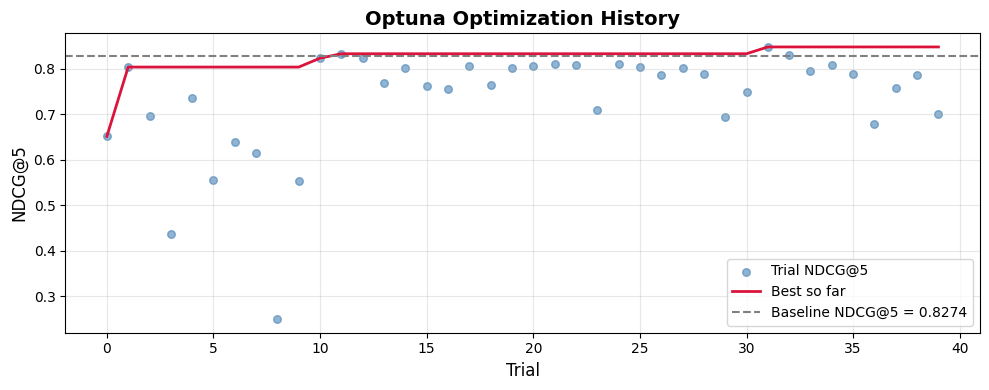

Saved optimization_history.png ✅


In [12]:
trial_nums = [t.number for t in study.trials]
trial_vals = [t.value for t in study.trials]

best_so_far = []
cur_best = -np.inf
for v in trial_vals:
    if v > cur_best:
        cur_best = v
    best_so_far.append(cur_best)

plt.figure(figsize=(10, 4))
plt.scatter(trial_nums, trial_vals, s=30, alpha=0.6, color='steelblue', label='Trial NDCG@5')
plt.plot(trial_nums, best_so_far, color='crimson', linewidth=2, label='Best so far')
plt.axhline(baseline_ndcg, color='grey', linestyle='--', linewidth=1.5, label=f'Baseline NDCG@5 = {baseline_ndcg}')
plt.xlabel('Trial', fontsize=12)
plt.ylabel('NDCG@5', fontsize=12)
plt.title('Optuna Optimization History', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('optimization_history.png', dpi=150)
plt.show()
print("Saved optimization_history.png ✅")

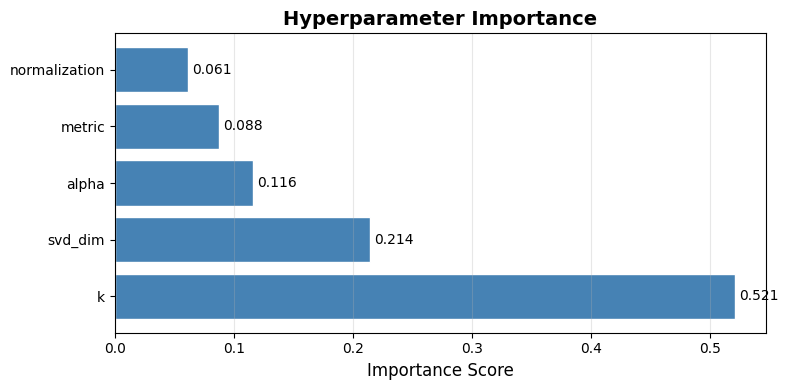

Saved param_importance.png ✅


In [13]:
importances = optuna.importance.get_param_importances(study)

params = list(importances.keys())
scores = list(importances.values())

plt.figure(figsize=(8, 4))
bars = plt.barh(params, scores, color='steelblue', edgecolor='white')
plt.bar_label(bars, fmt='{:.3f}', padding=3)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Hyperparameter Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('param_importance.png', dpi=150)
plt.show()
print("Saved param_importance.png ✅")

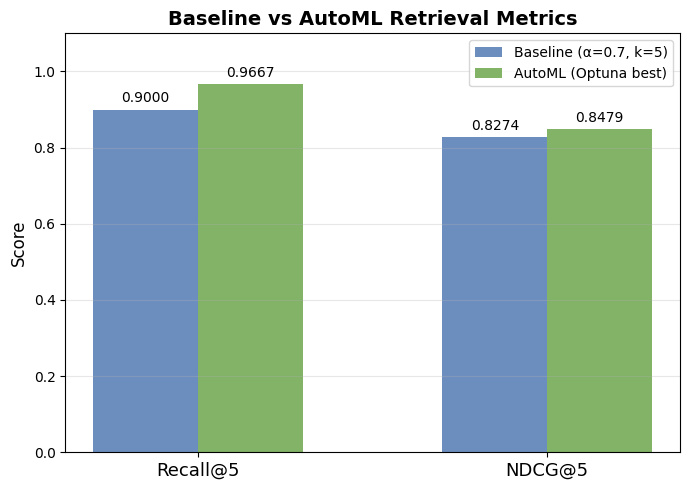

Saved baseline_vs_automl.png ✅


In [14]:
labels = ['Recall@5', 'NDCG@5']
base_vals   = [baseline_recall, baseline_ndcg]
automl_vals = [best.user_attrs['Recall@5'], round(best.value, 4)]

x = np.arange(2)
width = 0.3

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width/2, base_vals,   width, label='Baseline (α=0.7, k=5)', color='#6c8ebf')
b2 = ax.bar(x + width/2, automl_vals, width, label='AutoML (Optuna best)',  color='#82b366')
ax.bar_label(b1, fmt='{:.4f}', padding=3)
ax.bar_label(b2, fmt='{:.4f}', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Baseline vs AutoML Retrieval Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_vs_automl.png', dpi=150)
plt.show()
print("Saved baseline_vs_automl.png ✅")

In [15]:
comparison = pd.DataFrame([
    {
        'Method'         : 'Baseline (α=0.7, k=5, no SVD)',
        'Recall@5'       : baseline_recall,
        'NDCG@5'         : baseline_ndcg,
        'P95 Latency (s)': baseline_latency,
        'k'              : 5,
        'alpha'          : 0.7,
        'svd_dim'        : 'None',
        'metric'         : 'cosine',
        'normalization'  : 'N/A',
    },
    {
        'Method'         : 'AutoML Best (Optuna)',
        'Recall@5'       : best.user_attrs['Recall@5'],
        'NDCG@5'         : round(best.value, 4),
        'P95 Latency (s)': best.user_attrs['P95_Latency'],
        'k'              : best.params['k'],
        'alpha'          : round(best.params['alpha'], 3),
        'svd_dim'        : best.params['svd_dim'],
        'metric'         : best.params['metric'],
        'normalization'  : best.params['normalization'],
    },
])

comparison.to_csv('comparison_table.csv', index=False)
print("Saved comparison_table.csv ✅")
comparison

Saved comparison_table.csv ✅


,Method,Recall@5,NDCG@5,P95 Latency (s),k,alpha,svd_dim,metric,normalization
0,"Baseline (α=0.7, k=5, no SVD)",0.9000,0.8274,0.0852,5,0.700,None,cosine,N/A
1,AutoML Best (Optuna),0.9667,0.8479,0.0263,15,0.644,500,cosine,False


In [16]:
from google.colab import files

for f in ['best_config.yaml', 'optimization_history.png',
          'param_importance.png', 'baseline_vs_automl.png',
          'comparison_table.csv', 'embeddings.npy']:
    files.download(f)
    print(f"Downloaded {f} ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded best_config.yaml ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded comparison_table.csv ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded embeddings.npy ✅
